# ResNet-50 | Fine-tuning (Transfer Learning)
Multi-label clothing classification - 5 classes  
Init: ImageNet pretrained | Frozen: conv1, bn1, layer1, layer2 | Trainable: layer3, layer4, fc  
Loss: BCEWithLogitsLoss + pos_weight | Threshold: 0.5

## 1. Configuration

In [ ]:
import os, glob, pickle
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


BASE_DIR = '/kaggle/input/datasets/fashion/processed'

TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train', 'images')
VAL_IMG_DIR   = os.path.join(BASE_DIR, 'validation', 'images')

print(f'Dataset root : {BASE_DIR}')
print(f'Train images : {TRAIN_IMG_DIR}')
print(f'Val   images : {VAL_IMG_DIR}')

BATCH_SIZE  = 64
NUM_CLASSES = 5
NUM_EPOCHS  = 25     
LR          = 1e-4   
WEIGHT_DECAY = 1e-4
PATIENCE    = 5
THRESHOLD   = 0.5
CKPT        = '/kaggle/working/resnet50_finetune_best.pth'
CLASS_NAMES = ['short_sleeve_top', 'trousers', 'shorts',
               'long_sleeve_top', 'skirt']
SPLIT_FILE  = '/kaggle/working/val_test_split.pkl'
CKPT_DIR    = '/kaggle/working/checkpoints_finetune'
os.makedirs(CKPT_DIR, exist_ok=True)


FREEZE = ['conv1', 'bn1', 'layer1', 'layer2']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

## 2. Load Labels

In [ ]:
with open(os.path.join(BASE_DIR, 'train_labels.pkl'), 'rb') as f:
    train_labels = pickle.load(f)
with open(os.path.join(BASE_DIR, 'val_labels.pkl'), 'rb') as f:
    val_labels = pickle.load(f)

train_arr = np.array(list(train_labels.values())) 

print(f'Train: {len(train_labels):,}  |  Val: {len(val_labels):,}')
print('\nClass positives in train:')
for i, c in enumerate(CLASS_NAMES):
    p = int(train_arr[:, i].sum())
    print(f'  {c:<20}: {p:>6}  ({p/len(train_arr)*100:.1f}%)')

Train: 144,174  |  Val: 23,741

Class positives in train:
  short_sleeve_top    :  70586  (49.0%)
  trousers            :  54969  (38.1%)
  shorts              :  36332  (25.2%)
  long_sleeve_top     :  35751  (24.8%)
  skirt               :  30625  (21.2%)


## 3. Dataset & DataLoader

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class FashionDataset(Dataset):
    def __init__(self, labels_dict, img_root, transform=None):
        self.labels    = labels_dict
        self.filenames = list(labels_dict.keys())
        self.transform = transform
        self.img_root  = img_root

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, i):
        fname = self.filenames[i]
        img   = Image.open(os.path.join(self.img_root, fname)).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[fname], dtype=torch.float32)
        return img, label

_mean = [0.485, 0.456, 0.406]
_std  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=_mean, std=_std),
])

import pickle, random as _random


if os.path.exists(SPLIT_FILE):
    with open(SPLIT_FILE, 'rb') as f:
        _split = pickle.load(f)
    val_keys  = _split['val_keys']
    test_keys = _split['test_keys']
    print(f'Reused existing split — Val: {len(val_keys):,}  Test: {len(test_keys):,}')
else:
    _all_val = list(val_labels.keys())
    _random.seed(42)
    _random.shuffle(_all_val)
    n_test    = int(0.10 * len(_all_val))
    test_keys = _all_val[:n_test]
    val_keys  = _all_val[n_test:]
    with open(SPLIT_FILE, 'wb') as f:
        pickle.dump({'val_keys': val_keys, 'test_keys': test_keys}, f)
    print(f'Created split — Val: {len(val_keys):,}  Test: {len(test_keys):,}  (saved to {SPLIT_FILE})')

val_labels_split  = {k: val_labels[k] for k in val_keys}
test_labels_split = {k: val_labels[k] for k in test_keys}

train_ds = FashionDataset(train_labels,      TRAIN_IMG_DIR, train_tf)
val_ds   = FashionDataset(val_labels_split,  VAL_IMG_DIR,   val_tf)
test_ds  = FashionDataset(test_labels_split, VAL_IMG_DIR,   val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}')
xb, yb = next(iter(train_loader))
print('Batch image shape:', xb.shape)

Created split — Val: 21,367  Test: 2,374  (saved to /kaggle/working/val_test_split.pkl)
Train batches: 2253 | Val batches: 334 | Test batches: 38
Batch image shape: torch.Size([64, 3, 224, 224])


## 4. Model - Pretrained + Selective Freezing

In [4]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

for name, param in model.named_parameters():
    if any(name.startswith(l) for l in FREEZE):
        param.requires_grad = False

model.fc = nn.Linear(2048, NUM_CLASSES)
nn.init.kaiming_normal_(model.fc.weight, mode='fan_out', nonlinearity='relu')
nn.init.constant_(model.fc.bias, 0.0)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
print(f'Trainable: {trainable:,} | Frozen: {frozen:,}')

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s]


Trainable: 22,073,349 | Frozen: 1,444,928


## 5. Loss, Optimizer & Scheduler

In [ ]:
pos        = train_arr.sum(axis=0)
neg        = len(train_arr) - pos
pos_weight = torch.tensor(neg / pos, dtype=torch.float32).to(device)

print('pos_weight per class:')
for name, w in zip(CLASS_NAMES, pos_weight.cpu().tolist()):
    print(f'  {name:<20}: {w:.3f}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

pos_weight per class:
  short_sleeve_top    : 1.043
  trousers            : 1.623
  shorts              : 2.968
  long_sleeve_top     : 3.033
  skirt               : 3.708


## 6. Evaluation Function

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score

def evaluate(model, loader, criterion=None):
    model.eval()
    probs_list, labels_list = [], []
    total_vloss = 0.0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs_d, lbls_d = imgs.to(device), lbls.to(device)
            logits = model(imgs_d)
            probs_list.append(torch.sigmoid(logits).cpu().numpy())
            labels_list.append(lbls.numpy())
            if criterion:
                total_vloss += criterion(logits, lbls_d).item() * imgs.size(0)

    probs  = np.vstack(probs_list)
    labels = np.vstack(labels_list)
    preds  = (probs >= THRESHOLD).astype(int)

    per_class = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = int(((preds[:,i]==1) & (labels[:,i]==1)).sum())
        fp = int(((preds[:,i]==1) & (labels[:,i]==0)).sum())
        tn = int(((preds[:,i]==0) & (labels[:,i]==0)).sum())
        fn = int(((preds[:,i]==0) & (labels[:,i]==1)).sum())
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        f1   = 2*prec*rec / (prec + rec + 1e-8)
        auc  = roc_auc_score(labels[:,i], probs[:,i])
        ap   = average_precision_score(labels[:,i], probs[:,i])
        per_class[cls] = dict(TP=tp, FP=fp, TN=tn, FN=fn,
                               Precision=prec, Recall=rec, F1=f1, AUC=auc, AP=ap)

    macro_f1 = float(np.mean([v['F1'] for v in per_class.values()]))
    ttp = sum(v['TP'] for v in per_class.values())
    tfp = sum(v['FP'] for v in per_class.values())
    tfn = sum(v['FN'] for v in per_class.values())
    mp  = ttp / (ttp + tfp + 1e-8)
    mr  = ttp / (ttp + tfn + 1e-8)
    micro_f1 = 2*mp*mr / (mp + mr + 1e-8)

    hamming_acc = float((preds == labels).mean())
    exact_match = float((preds == labels).all(axis=1).mean())
    mAP         = float(np.mean([v['AP'] for v in per_class.values()]))

    val_loss = total_vloss / len(loader.dataset) if criterion else None
    return per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, probs, labels, val_loss

## 7. Training

In [7]:
history = {'train_loss':[], 'val_loss':[], 'macro_f1':[], 'micro_f1':[]}
best_macro_f1  = 0.0
patience_count = 0
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    run_loss = 0.0
    for imgs, lbls in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}', leave=False):
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad(set_to_none=True)
        if scaler:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                loss = criterion(model(imgs), lbls)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss = criterion(model(imgs), lbls)
            loss.backward()
            optimizer.step()
        run_loss += loss.item() * imgs.size(0)
    train_loss = run_loss / len(train_ds)

    per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, _, _, val_loss = \
        evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['macro_f1'].append(macro_f1)
    history['micro_f1'].append(micro_f1)

    print(f'Ep {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
          f'macro_f1={macro_f1:.4f} | micro_f1={micro_f1:.4f} | '
          f'hamming={hamming_acc:.4f} | mAP={mAP:.4f}')
    scheduler.step(macro_f1)

    if macro_f1 > best_macro_f1:
        best_macro_f1 = macro_f1
        patience_count = 0
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'macro_f1'         : macro_f1,
            'micro_f1'         : micro_f1,
            'per_class_metrics': per_class,
        }, CKPT)
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model.state_dict(),
            'macro_f1'         : macro_f1,
            'micro_f1'         : micro_f1,
            'per_class_metrics': per_class,
        }, os.path.join(CKPT_DIR, f'epoch_{epoch:02d}_f1_{macro_f1:.4f}.pth'))
        print(f'  ✓ Best model saved (macro-F1={macro_f1:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

print(f'\nBest val macro-F1: {best_macro_f1:.4f}')

Epoch 1/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 01 | train_loss=0.6045 | val_loss=0.4466 | macro_f1=0.7732 | micro_f1=0.7876 | hamming=0.8544 | mAP=0.8722
  ✓ Best model saved (macro-F1=0.7732)


Epoch 2/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 02 | train_loss=0.3949 | val_loss=0.4317 | macro_f1=0.7911 | micro_f1=0.8039 | hamming=0.8703 | mAP=0.8852
  ✓ Best model saved (macro-F1=0.7911)


Epoch 3/25:   0%|          | 0/2253 [00:00<?, ?it/s]

...

Ep 20 | train_loss=0.0190 | val_loss=0.9348 | macro_f1=0.8126 | micro_f1=0.8281 | hamming=0.8893 | mAP=0.8933


Epoch 21/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 21 | train_loss=0.0182 | val_loss=0.9456 | macro_f1=0.8112 | micro_f1=0.8254 | hamming=0.8883 | mAP=0.8907


Epoch 22/25:   0%|          | 0/2253 [00:00<?, ?it/s]

Ep 22 | train_loss=0.0132 | val_loss=0.9761 | macro_f1=0.8134 | micro_f1=0.8277 | hamming=0.8902 | mAP=0.8959

Early stopping at epoch 22.

Best val macro-F1: 0.8138


## 8. Final Evaluation (best checkpoint)

In [ ]:
ckpt = torch.load(CKPT, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
per_class, macro_f1, micro_f1, hamming_acc, exact_match, mAP, all_probs, all_labels, _ = \
    evaluate(model, test_loader, criterion)   

print('=' * 88)
print(f'  ResNet-50 Fine-tuned — TEST SET  |  Best epoch: {ckpt["epoch"]}  |  Threshold: {THRESHOLD}')
print('=' * 88)
print(f'{"Class":<22} {"TP":>7} {"FP":>7} {"TN":>7} {"FN":>7} '
      f'{"Prec":>7} {"Rec":>7} {"F1":>7} {"AUC":>7} {"AP":>7}')
print('-' * 88)
for cls in CLASS_NAMES:
    m = per_class[cls]
    print(f'{cls:<22} {m["TP"]:>7} {m["FP"]:>7} {m["TN"]:>7} {m["FN"]:>7} '
          f'{m["Precision"]:>7.4f} {m["Recall"]:>7.4f} {m["F1"]:>7.4f} '
          f'{m["AUC"]:>7.4f} {m["AP"]:>7.4f}')
print('-' * 88)
print(f'{"Macro-F1":<22} {macro_f1:>7.4f}')
print(f'{"Micro-F1":<22} {micro_f1:>7.4f}')
print(f'{"mAP":<22} {mAP:>7.4f}')
print(f'{"Hamming Accuracy":<22} {hamming_acc:>7.4f}')
print(f'{"Exact Match":<22} {exact_match:>7.4f}')

  ResNet-50 Fine-tuned — TEST SET  |  Best epoch: 17  |  Threshold: 0.5
Class                       TP      FP      TN      FN    Prec     Rec      F1     AUC      AP
----------------------------------------------------------------------------------------
short_sleeve_top          1034     152     987     201  0.8718  0.8372  0.8542  0.9377  0.9448
trousers                   810     146    1267     151  0.8473  0.8429  0.8451  0.9456  0.9320
shorts                     323     119    1840      92  0.7308  0.7783  0.7538  0.9413  0.8441
long_sleeve_top            435     125    1657     157  0.7768  0.7348  0.7552  0.9381  0.8467
skirt                      536      90    1645     103  0.8562  0.8388  0.8474  0.9621  0.9150
----------------------------------------------------------------------------------------
Macro-F1                0.8111
Micro-F1                0.8245
mAP                     0.8965
Hamming Accuracy        0.8874
Exact Match             0.6243


## 9. ROC Curves

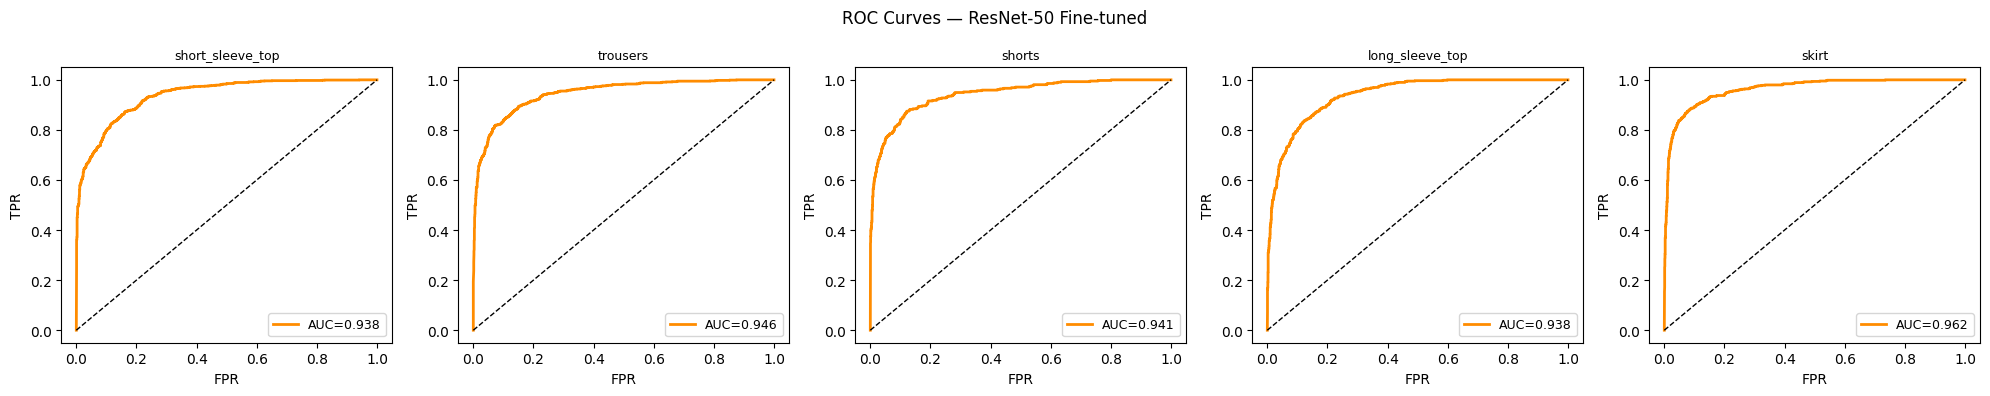

In [9]:
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))
for i, (cls, ax) in enumerate(zip(CLASS_NAMES, axes)):
    fpr, tpr, _ = roc_curve(all_labels[:, i], all_probs[:, i])
    ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC={per_class[cls]["AUC"]:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_title(cls, fontsize=9)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(fontsize=9)
plt.suptitle('ROC Curves — ResNet-50 Fine-tuned', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/roc_finetune.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Training Curves

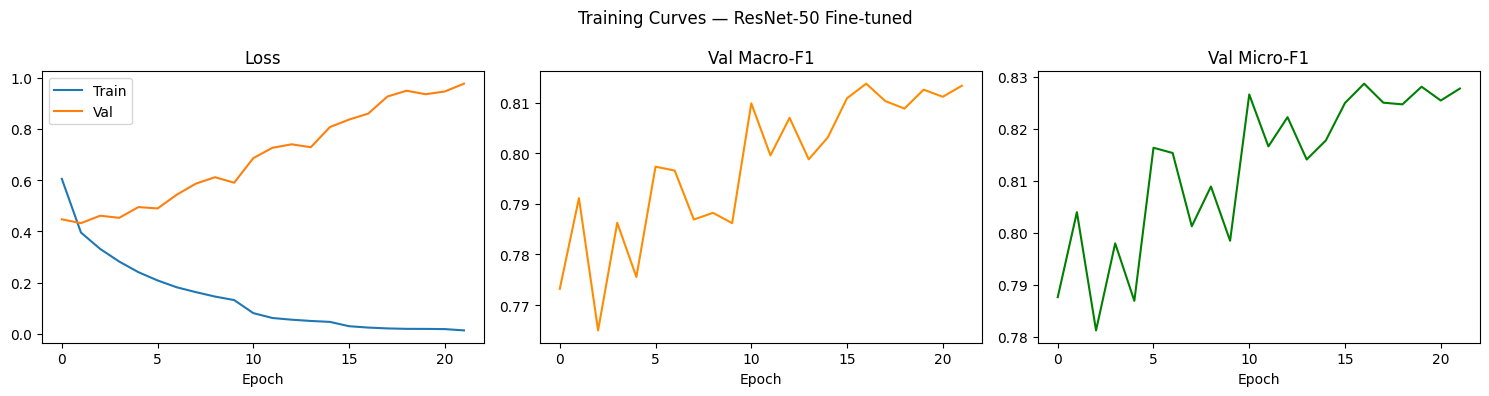

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history['macro_f1'], color='darkorange')
axes[1].set_title('Val Macro-F1'); axes[1].set_xlabel('Epoch')
axes[2].plot(history['micro_f1'], color='green')
axes[2].set_title('Val Micro-F1'); axes[2].set_xlabel('Epoch')
plt.suptitle('Training Curves — ResNet-50 Fine-tuned', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/curves_finetune.png', dpi=150, bbox_inches='tight')
plt.show()